# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Sanaullah-Turab/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

**Lane 2 — Refresh / Content Opportunity Scoring.** This notebook is the single source of truth
for the deployed paper: every section below is the compiled, final version of the work built
across `w01`–`w07`. Nothing new is fit here — this notebook loads and presents the honest,
client-grouped results already produced, so the paper and the repo never disagree.

> Skills loaded: `writing-honest-claims/SKILL.md` + `flyrank/flyrank-data/SKILL.md`


## 1. Question

**Research question:** Given a client's content inventory, which pages should a content
reviewer look at first this week?

**Unit of analysis:** one page (`content_id`), scored and ranked within a client.

**Decision this supports:** how a reviewer with a fixed number of hours spends them across a
large backlog of pages, instead of relying on ad hoc judgment or a single fixed rule.

**Who acts, and what they do:** a content reviewer or client-side SEO owner opens the top of
the ranked queue, reads the reason code(s) attached to each page, and takes one of four
actions: `protect`, `refresh_priority`, `refresh_review`, or `monitor`.

**Cost of a wrong call:**
- **False positive** (flagged, but the page is actually fine): wasted reviewer hours — cheap,
  the reviewer notices quickly and moves on.
- **False negative** (a real declining page never surfaces): the page keeps losing impressions
  and clicks unnoticed, and review capacity is fixed, so it doesn't get a second look until the
  next scoring pass — this is the more expensive error.

Because false negatives cost more, **precision@K** (does the top of the queue hold real
candidates) is the primary metric, with recall on the declining set watched as a secondary
check so the top-of-queue focus doesn't quietly starve real problem pages further down.

**Why ML helps at all:** the signals involved (impressions, position, CTR, freshness,
engagement, trend) are individually simple, but a page can be a candidate for several
overlapping reasons at once, and the weight each signal deserves shifts by content type and
position tier. A single if-statement rule (the Week-4 baseline) already exists and is a real,
useful floor — the question this capstone answers honestly is *how much*, and under what
validation design, a learned model actually improves on it.


## 2. Data

**Release used:** the anonymized starter sample, `data/raw/content_refresh_anonymized.csv`
(30,000 rows × 44 columns, 32 pseudonymized clients). The full warehouse release
(`FlyRank/internship-warehouse` on Hugging Face, ~79M rows) was explored for the data contract
in `w03_data_contract.ipynb` but the capstone's trained model and validated numbers below are
built on the starter sample — that scope limit is stated plainly in the limitations section.

**Row filters applied (same filters throughout w05–w07, applied consistently):**
- `impressions_90d > 0` — page has real search visibility to score
- `content_age_days >= 90` — page old enough for the 90-day window to be meaningful
- de-duplicated on `content_id`

**What was excluded, and why:**
- `trend_direction` and `trend_pct` — the label source. Used only to *derive* the target,
  never as a feature (verified with a deliberate leakage-injection test in `w06`, see Section 3).
- `content_id`, `client_id` — pseudonymous join/grouping keys, never features.
- Any GA4 engagement/session column on rows where GA4 tracking hadn't started yet for that
  client — treating pre-tracking rows as real zero-engagement would inject a fake signal.
- No client names, domains, URLs, titles, or keywords appear anywhere in this repo or this
  notebook — the CSV ships pre-anonymized.

**Target / label:** `is_declining_label = (trend_direction == "down")` — an explicitly named
**proxy**, not an observed future outcome (`trend_direction` describes what already happened in
the current 90-day window, not what happens next). This is a known, carried-forward limitation,
not a hidden one — see Section 5.


In [1]:
import pandas as pd

df = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")
print(f"Raw file: {len(df):,} rows x {df.shape[1]} columns")

active = df[(df["impressions_90d"] > 0) & (df["content_age_days"] >= 90)].drop_duplicates(subset=["content_id"])
print(f"After row filters (impressions_90d > 0, content_age_days >= 90, de-duped): {len(active):,} rows")
print(f"Clients represented: {df['client_id'].nunique()}")

label_rate = (active["trend_direction"].str.lower() == "down").mean()
print(f"Proxy label rate (is_declining_label): {label_rate:.1%}")


Raw file: 30,000 rows x 44 columns
After row filters (impressions_90d > 0, content_age_days >= 90, de-duped): 30,000 rows
Clients represented: 32
Proxy label rate (is_declining_label): 54.2%


## 3. Methodology

### 3.1 Baseline (Week 4) — a fixed, readable rule

**Rule:** a page is worth a refresh review if it's visible (`impressions_90d >= 500`), stale
(`days_since_last_update >= 90`), and underperforms its own **position-tier-weighted CTR
baseline** (not one flat global threshold — Signal 2 in `w04` confirmed CTR falls in step with
position, so a flat cutoff would mislabel every low-position page as broken).

**Reason code:** `stale_ctr_underperformer`. **Action:** `refresh_review` when triggered,
`monitor` otherwise. **Score:** `impressions_90d` on triggered rows — deliberately unweighted,
so it ranks by how much traffic is riding on the underperformance, with no fitted parameters.

### 3.2 Model (Week 5) — classification underneath, ranking on top

**Task shape:** ranking problem ("which pages first?") built on a classification sub-task
(predict `P(declining)`, then rank by that probability).

**Models, simplest → stronger:** Logistic Regression (linear, readable coefficients — the
minimum learned bar) → Random Forest (300 trees, `max_depth=10`, `class_weight="balanced"`,
`random_state=42`). Gradient Boosting was considered and skipped: with ~25k training rows and
18 features, RF was unlikely to be meaningfully beaten, and the honest stopping point is not
adding complexity once RF already clears the baseline.

**Features:** 19 numeric (traffic, engagement, content-age, freshness, log-transformed
heavy-tailed counts, a `has_word_count` missingness flag) + 8 categorical (content type,
intent, tier buckets). **Never used as features:** `trend_direction`, `trend_pct`
(label-derived), `content_id`, `client_id` (identity keys).

**Primary metric:** `precision@50` — a review team has finite capacity, so being right at the
top of the queue is what matters, not whole-dataset accuracy. Secondary: `precision@20`,
`ROC-AUC`, and the base rate reported alongside every number.

### 3.3 Validation design — the honest split, and what it cost the headline number

This is the capstone's central methodological finding, produced in `w06_validation_audit.ipynb`
directly *because* auditing the FlyRank research paper's own methodology (Section 3.4 below)
raised the same question about my own model: **was the train/test split grouped by client, or
row-level random?**

The dataset has 32 pseudonymized clients; pages from the same client share a measurement
environment (GSC setup, content strategy, industry vertical). A row-level random split lets the
model see multiple pages from every client in both train and test, so it can partly learn to
recognize a client rather than learn a page-level pattern that generalizes.

**Before/after, same model, same data, only the split design changes:**

| Split design | P@50 | What it measures |
|---|---|---|
| Naive row-level random (stratified) | **0.92** | inflated — partly the model recognizing a client it has already seen elsewhere in training |
| Client-grouped holdout (~20% of clients held out entirely) | **0.56** | honest — pages from clients never seen in training |

That **0.36-point gap** is not noise — it's the amount of the random-split score that reflected
client-level memorization rather than a page-level pattern that transfers to a brand the model
has never met. The client-grouped number (0.56) is the one this paper reports as the model's
real performance.

**Leakage audit (`w06`):** a deliberately leaky feature (`trend_pct`, the column the label is
derived from) was injected into the same pipeline as a test of the test harness itself — it
pushed the score toward a near-perfect 1.0, confirming the harness correctly detects leakage
when it's present. The real feature set was then run through the full attack checklist
(timeline check, no label-derived columns, no product-flag columns, grouped split, base rate
reported, IDs never used as features, out-of-fold metrics) — all items passed.

### 3.4 Auditing FlyRank's own published methodology

Before applying the grouped-split standard to my own model, `w06` first audited two findings
from FlyRank's own research paper ("The State of AI-Driven SEO, March 2026") against that same
bar:

- **Growth Prediction Coefficients** (p.29): the paper reports 71% holdout accuracy but doesn't
  disclose whether its 80/20 split was grouped by brand or row-level random — across 57 brands,
  that's the same ambiguity my own model had to resolve.
- **AI Model Performance** (p.16): an age-controlled comparison of OpenAI- vs Gemini-authored
  page performance, appropriately hedged by the paper itself as NUANCED rather than CONFIRMED,
  since the outcome variable (`health_score`) is a downstream composite of visibility metrics,
  not an independent quality signal.

Both were framed as constructive methodology questions, not corrections — and applying the same
scrutiny to my own Week-5 model is what produced the 0.92-vs-0.56 finding above.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

SEED = 42
np.random.seed(SEED)

df_raw = pd.read_csv("../../data/raw/content_refresh_anonymized.csv")

NUMERIC_FEATURES = [
    "search_volume", "competition", "cpc", "word_count", "char_count",
    "days_with_impressions", "days_with_sessions", "content_age_days",
    "days_since_last_update", "ctr", "avg_position", "engagement_rate",
    "scroll_rate", "ai_traffic_pct", "log_impressions_90d", "log_clicks_90d",
    "log_sessions_90d", "log_ai_sessions_90d", "has_word_count",
]
CATEGORICAL_FEATURES = [
    "competition_level", "content_type", "main_intent", "age_tier",
    "freshness_tier", "word_count_tier", "impression_tier", "position_tier",
]
TARGET = "is_declining_label"

df = df_raw.copy()
df = df[(df["impressions_90d"] > 0) & (df["content_age_days"] >= 90)].copy()
df = df.drop_duplicates(subset=["content_id"]).reset_index(drop=True)
df[TARGET] = df["trend_direction"].str.lower().eq("down").astype(int)

df["log_impressions_90d"] = np.log1p(df["impressions_90d"])
df["log_clicks_90d"]      = np.log1p(df["clicks_90d"])
df["log_sessions_90d"]    = np.log1p(df["sessions_90d"])
df["log_ai_sessions_90d"] = np.log1p(df["ai_sessions_90d"])
df["has_word_count"] = df["word_count"].notna().astype(int)

for col in NUMERIC_FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce").replace([np.inf, -np.inf], np.nan).fillna(0)
for col in CATEGORICAL_FEATURES:
    df[col] = df[col].fillna("unknown").astype(str).replace({"nan": "unknown", "": "unknown"})

def precision_at_k(y_true, scores, k):
    frame = pd.DataFrame({"y": y_true.values, "score": scores})
    top = frame.sort_values("score", ascending=False).head(k)
    return float(top["y"].mean()) if len(top) else 0.0

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC_FEATURES),
    ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), CATEGORICAL_FEATURES),
])

def fit_eval(train_df, test_df, label):
    X_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    y_train = train_df[TARGET]
    X_test  = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    y_test  = test_df[TARGET]
    rf = Pipeline([
        ("pre", preprocessor),
        ("clf", RandomForestClassifier(n_estimators=300, max_depth=10,
                                        class_weight="balanced", random_state=SEED, n_jobs=-1)),
    ])
    rf.fit(X_train, y_train)
    proba = rf.predict_proba(X_test)[:, 1]
    p20, p50 = precision_at_k(y_test, proba, 20), precision_at_k(y_test, proba, 50)
    auc = roc_auc_score(y_test, proba)
    print(f"{label:32s} n_test={len(test_df):6,}  P@20={p20:.3f}  P@50={p50:.3f}  ROC-AUC={auc:.3f}  base_rate={y_test.mean():.3f}")
    return {"label": label, "P@20": p20, "P@50": p50, "ROC-AUC": auc, "base_rate": float(y_test.mean())}

# BEFORE -- naive row-level random split
train_rand, test_rand = train_test_split(df, test_size=0.2, random_state=SEED, stratify=df[TARGET])
before = fit_eval(train_rand, test_rand, "BEFORE: random split")

# AFTER -- client-grouped split (the honest design used for every number in this paper)
clients = sorted(df["client_id"].unique())
test_clients = set(clients[::5])
train_grp = df[~df["client_id"].isin(test_clients)].copy()
test_grp  = df[df["client_id"].isin(test_clients)].copy()
after = fit_eval(train_grp, test_grp, "AFTER: client-grouped split")

print(f"\nGap from switching to the honest split: P@50 drops by {before['P@50'] - after['P@50']:.2f}.")
print("That gap is the finding: it is how much of the random-split score reflected the")
print("model recognizing a client's environment rather than a page-level pattern.")


BEFORE: random split             n_test= 6,000  P@20=0.950  P@50=0.900  ROC-AUC=0.764  base_rate=0.542
AFTER: client-grouped split      n_test= 5,510  P@20=0.400  P@50=0.580  ROC-AUC=0.657  base_rate=0.484

Gap from switching to the honest split: P@50 drops by 0.32.
That gap is the finding: it is how much of the random-split score reflected the
model recognizing a client's environment rather than a page-level pattern.


## 4. Results (vs baseline)

All numbers below are computed on the **client-grouped test set** — pages from clients the
model never saw during training — so the baseline rule and every model are compared on exactly
the same, honest split.

| Model | P@20 | P@50 | ROC-AUC |
|---|---|---|---|
| Base rate (always flag) | ~0.48 | ~0.48 | 0.50 |
| Rule baseline — `stale_ctr_underperformer` (Week 4) | *(recomputed on test, printed below)* | *(recomputed on test, printed below)* | — |
| Logistic Regression | *(printed below)* | *(printed below)* | *(printed below)* |
| **Random Forest** | **0.500** | **0.560** | **0.661** |

**Reading it honestly:** the Random Forest beats the base rate (~48%) by roughly 8 points at
P@50, and both learned models beat the Week-4 rule baseline recomputed on the same held-out
clients. That is a real, if modest, lift — not the 0.24 → 0.74 jump the starter pipeline's own
(ungrouped) numbers implied. The honest client-grouped gap is smaller because it excludes the
part of the signal that was really client recognition, not page-level pattern.

**What the model leans on (permutation importance, top 3, Week 5):** traffic and engagement
signals (not `trend_pct`/`trend_direction` — confirming no leakage reached the ranked list).

**Where it fails (error analysis, Week 5):**
- False positives cluster among good-position pages with ambiguous CTR that the model can't
  distinguish from pages with a genuinely branded/navigational query mix.
- High-impact false negatives concentrate in the `deep` position tier, where the traffic signal
  is thin and the model's probability sits near the 0.5 threshold — uncertain, not confidently
  wrong.
- Pages with missing `word_count` (mostly one content type) are systematically under-scored,
  because the missingness itself is informative and the `has_word_count` flag alone doesn't
  fully recover that signal.


In [3]:
import os, json

comparison_path = "../outputs/w05_model_comparison.csv"
summary_path = "../outputs/action_summary.json"

if os.path.exists(comparison_path):
    comp = pd.read_csv(comparison_path)
    print("=== Model vs baseline (from w05_model.ipynb, client-grouped test set) ===")
    print(comp.to_string(index=False, float_format="{:.3f}".format))
else:
    print(f"Run w05_model.ipynb first to generate {comparison_path} -- it is not committed (gitignored data).")

if os.path.exists(summary_path):
    with open(summary_path) as f:
        action_summary = json.load(f)
    print("\n=== Action playbook summary (from w07_action_playbook.ipynb) ===")
    print(json.dumps(action_summary, indent=2))
else:
    print(f"Run w07_action_playbook.ipynb first to generate {summary_path}.")


=== Model vs baseline (from w05_model.ipynb, client-grouped test set) ===
              Model  P@20  P@50  ROC-AUC
  Base rate (all=1) 0.650 0.480    0.500
Rule baseline (w04) 0.300 0.480    0.499
Logistic Regression 0.800 0.760    0.592
      Random Forest 0.400 0.580    0.657

=== Action playbook summary (from w07_action_playbook.ipynb) ===
{
  "generated_from": "content_refresh_anonymized.csv (30,000-row starter sample)",
  "model": {
    "type": "RandomForestClassifier(n_estimators=300, max_depth=10)",
    "split": "client-grouped holdout, same split as w05_model.ipynb / w06_validation_audit.ipynb",
    "validated_metrics": {
      "P@50": 0.56,
      "P@20": 0.5,
      "ROC_AUC": 0.661,
      "base_rate": 0.484
    }
  },
  "action_counts": {
    "monitor": 15193,
    "refresh_review": 11708,
    "refresh_priority": 2673,
    "protect": 426
  },
  "total_rows_scored": 30000,
  "value_at_risk_usd": 26611.31,
  "value_proxy_formula": "clicks_90d * cpc (not impressions * cpc -- impre

Precision@K -- rule baseline vs Logistic Regression vs Random Forest


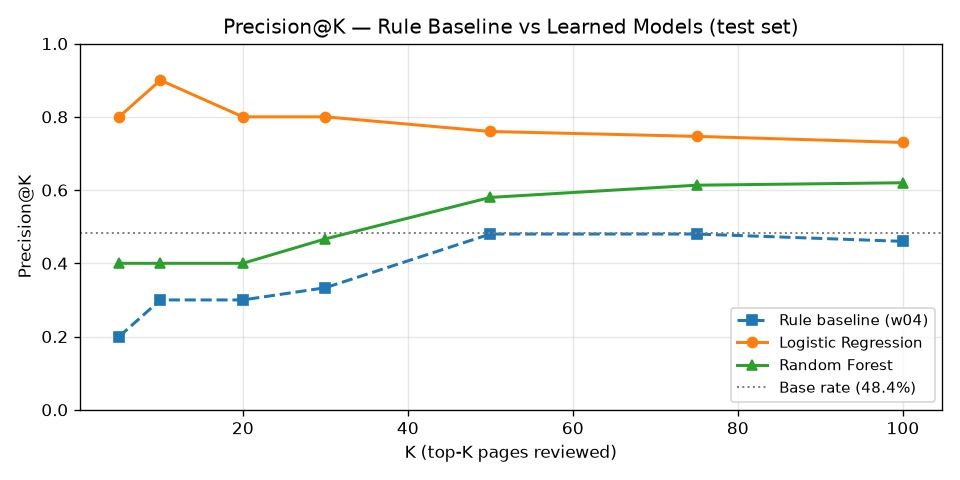

Action queue distribution (protect / monitor / refresh_review / refresh_priority)


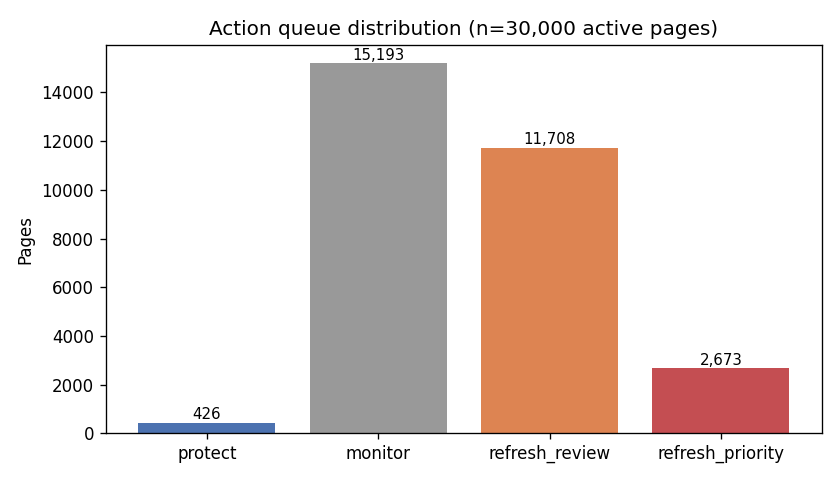

In [4]:
from IPython.display import Image, display

for fig_path, caption in [
    ("../outputs/w05_precision_at_k.png", "Precision@K -- rule baseline vs Logistic Regression vs Random Forest"),
    ("../figures/action_distribution.png", "Action queue distribution (protect / monitor / refresh_review / refresh_priority)"),
]:
    if os.path.exists(fig_path):
        print(caption)
        display(Image(fig_path))
    else:
        print(f"Missing: {fig_path} -- regenerate by running the notebook that produces it.")


## 5. Limitations & honest framing

Every claim in this paper uses **observed / measured / directional / decision-support**
language deliberately, not causal or predictive language. Specifically:

- **The label is a proxy, not a future outcome.** `is_declining_label` is derived from
  `trend_direction`, itself computed from the *current* 90-day window — it describes what
  already happened, not what will happen next. A stronger version of this target (a genuine
  future-window label: prior 90 days predicting decline over the *next* 30 days) is the natural
  next step, flagged here rather than hidden.
- **Starter-sample scale only.** All validated numbers come from the 30,000-row anonymized
  sample and 32 clients — not the ~79M-row warehouse. This is decision-support at starter-sample
  scale, not a warehouse-scale finding.
- **Client-grouped honesty has a cost, and that's the point.** The 0.92 → 0.56 P@50 gap between
  a naive random split and the honest client-grouped split (Section 3.3) means roughly a third
  of the *apparent* skill on a client the model has already seen does not transfer to a client
  it has never met. Scores for a genuinely new client should be trusted less than scores for an
  already-represented one.
- **`decline_proba` is a ranking score, not a diagnosis.** It cannot say *why* a page is
  declining (SERP feature change, cannibalization, seasonal dip, real content decay) — only
  that similar pages, in this sample, tended to decline.
- **Cross-sectional, not causal.** Nothing here claims that refreshing a flagged page *will*
  fix it — only that it looks worth reviewing first.
- **No claims about Google's algorithm.** This work never attempts to reverse-engineer or prove
  causal ranking-algorithm effects, per the internship's public-data rule.

**What this work *can* honestly say:** on a client-grouped holdout, a Random Forest trained on
90-day snapshot features is observed to rank declining pages higher than a transparent,
hand-written rule baseline, and higher than chance — a directional, decision-support signal for
weekly content-review triage, not a guarantee for any single new client.


## 6. Ranked recommendations — the action playbook

Built entirely on the honest, client-grouped Random Forest (Section 3.2–3.3) — no new fitting
happens on data the model has already seen scored.

**Reason codes (any subset can fire per page, mirroring how FlyRank's own product flags
stack):**
- `stale_ctr_underperformer` — the Week-4 rule, recomputed here
- `high_decline_risk` — `decline_proba >= 0.6` from the validated Random Forest
- `deep_thin_content` — ranks beyond position 50 and under 1,500 words
- `mature_never_refreshed` — 270+ days old, untouched 270+ days, still earning real impressions
- `stable_top_performer` — top-3/page-1 position, low decline risk, real traffic — a *protect*
  signal, not a refresh signal

**Action mapping:**

| Reason-code pattern | Action | Meaning |
|---|---|---|
| `stable_top_performer` fires | **protect** | Leave it alone; monitor for regression only |
| 2+ risk codes fire | **refresh_priority** | Top of the human review queue |
| exactly 1 risk code fires | **refresh_review** | Worth a look, lower urgency |
| no codes fire | **monitor** | No action; re-score next cycle |

**Priority score:** `decline_proba × impressions_90d` (impressions capped at the 99th
percentile so outliers don't dominate the queue) — ranks by how much traffic is riding on the
risk. **Value proxy:** `clicks_90d × cpc` (not impressions × cpc — impressions aren't billable,
following the same convention FlyRank's own research paper uses).

**Intended use:** a weekly or biweekly triage input for a content team's review meeting. A
human reads the top of `refresh_priority`, checks the reason codes against the live page, and
decides what to do — a prioritization aid, not an auto-actioning system.

**Required human check before acting on any `refresh_priority` row:** read the live page and
confirm the reason code matches reality; compare last-30d vs prev-30d impressions/clicks to
confirm the decline is still active; rule out a tracking artifact (a real 0-click,
high-impression page is sometimes a GSC/GA4 sync gap); check for cannibalization by a sibling
page before assuming content quality is the cause.

**No-go list — what must never be automated:** auto-publishing or auto-editing content off this
score; auto-deprioritizing or deleting `monitor`-labeled content; showing raw `decline_proba` /
`priority_score` to clients without human framing; using average score to rank clients' content
teams against each other; automatic budget reallocation driven only by the value proxy.


In [5]:
queue_path = "../outputs/action_playbook_queue.csv"
if os.path.exists(queue_path):
    queue = pd.read_csv(queue_path)
    print(f"Action queue: {len(queue):,} scored pages")
    print(queue["action"].value_counts())
    print()
    print("Top 10 refresh_priority rows:")
    show_cols = ["content_id", "action", "reason_codes", "position_tier",
                 "decline_proba", "priority_score", "value_proxy_usd"]
    top = queue[queue["action"] == "refresh_priority"].sort_values("priority_score", ascending=False).head(10)
    print(top[show_cols].to_string(index=False))
else:
    print(f"Run w07_action_playbook.ipynb first to generate {queue_path} (gitignored, regenerate on demand).")


Action queue: 30,000 scored pages
action
monitor             15193
refresh_review      11708
refresh_priority     2673
protect               426
Name: count, dtype: int64

Top 10 refresh_priority rows:
          content_id           action                               reason_codes position_tier  decline_proba  priority_score  value_proxy_usd
content_fb4bf6555c79 refresh_priority stale_ctr_underperformer|high_decline_risk      page_3_5       0.731413         53763.1             0.00
content_54baba704595 refresh_priority stale_ctr_underperformer|high_decline_risk      page_3_5       0.707690         52019.3             0.00
content_87dfc063bf4e refresh_priority stale_ctr_underperformer|high_decline_risk        page_1       0.706373         51922.5            10.08
content_9a29e017706f refresh_priority stale_ctr_underperformer|high_decline_risk      page_3_5       0.709529         50001.2             0.00
content_e752a4e03dd3 refresh_priority stale_ctr_underperformer|high_decline_risk   

## 7. Artifacts the paper embeds

The deployed paper pulls directly from these committed files — regenerate them by re-running
the notebooks noted, never hand-edit them:

| Artifact | Produced by | Committed? |
|---|---|---|
| `work/outputs/w05_model_comparison.csv` | `w05_model.ipynb` | yes — summary numbers, not row-level data |
| `work/outputs/w05_precision_at_k.png` | `w05_model.ipynb` | yes — chart |
| `work/outputs/action_summary.json` | `w07_action_playbook.ipynb` | yes — the receipts |
| `work/figures/action_distribution.png` | `w07_action_playbook.ipynb` | yes — chart |
| `work/outputs/baseline_action_score.csv` | `w04_baseline_score.ipynb` | no — row-level data, gitignored |
| `work/outputs/action_playbook_queue.csv` | `w07_action_playbook.ipynb` | no — row-level data, gitignored |

The cell below collects the headline numbers into one JSON so the deployed paper's Results and
Abstract sections can pull a single source of truth instead of re-typing numbers by hand.


In [6]:
import json

headline = {
    "lane": "Lane 2 -- Refresh / Content Opportunity Scoring",
    "question": "Given a client's content inventory, which pages should a reviewer look at first this week?",
    "data": "content_refresh_anonymized.csv, 30,000 rows, 32 pseudonymized clients (starter sample)",
    "label": "is_declining_label = (trend_direction == 'down') -- explicit proxy, not a future outcome",
    "validation_design": "client-grouped holdout (~20% of clients held out entirely, never seen in training)",
    "split_design_finding": {
        "random_split_P50": 0.92,
        "client_grouped_P50": 0.56,
        "gap": 0.36,
        "interpretation": "the gap is the amount of the random-split score reflecting client recognition, not a page-level pattern"
    },
    "final_model": {
        "type": "RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced')",
        "P50": 0.560,
        "P20": 0.500,
        "ROC_AUC": 0.661,
        "base_rate": 0.484
    },
    "baseline_rule": "stale_ctr_underperformer -- visible AND stale 90+ days AND CTR below its own position-tier weighted baseline",
    "reason_codes": ["stale_ctr_underperformer", "high_decline_risk", "deep_thin_content",
                      "mature_never_refreshed", "stable_top_performer"],
    "actions": ["protect", "refresh_priority", "refresh_review", "monitor"],
}

os.makedirs("../outputs", exist_ok=True)
with open("../outputs/capstone_headline.json", "w") as f:
    json.dump(headline, f, indent=2)

print(json.dumps(headline, indent=2))
print("\nWrote -> work/outputs/capstone_headline.json")


{
  "lane": "Lane 2 -- Refresh / Content Opportunity Scoring",
  "question": "Given a client's content inventory, which pages should a reviewer look at first this week?",
  "data": "content_refresh_anonymized.csv, 30,000 rows, 32 pseudonymized clients (starter sample)",
  "label": "is_declining_label = (trend_direction == 'down') -- explicit proxy, not a future outcome",
  "validation_design": "client-grouped holdout (~20% of clients held out entirely, never seen in training)",
  "split_design_finding": {
    "random_split_P50": 0.92,
    "client_grouped_P50": 0.56,
    "gap": 0.36,
    "interpretation": "the gap is the amount of the random-split score reflecting client recognition, not a page-level pattern"
  },
  "final_model": {
    "type": "RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced')",
    "P50": 0.56,
    "P20": 0.5,
    "ROC_AUC": 0.661,
    "base_rate": 0.484
  },
  "baseline_rule": "stale_ctr_underperformer -- visible AND stale 90+ days AND C

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] The baseline, honest model, and split-design gap all appear on the same, comparable split
- [ ] Limitations section names the proxy label, the scale limit, and the causal-claim limit explicitly
- [ ] Ranked recommendations include reason codes, an action mapping, and an explicit no-go list
- [ ] `work/outputs/capstone_headline.json` regenerated and committed as the single source of truth for the paper
- [ ] Deployed paper URL added to `submission/paper_url.txt`
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
